<a href="https://colab.research.google.com/github/ramstrone/ATA-Assignment-2/blob/main/agent_qwen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT3103 Assignment 2 — Multimodal Agent with Qwen3-VL

**Agentic AI** — Build a visual **ReAct + Reflexion** agent.

> **Agent = LLM + Loop + Tools + Memory + Self-Correction**

This starter notebook gives you the scaffolding. Sections marked **`# TODO`** are yours to complete.

**Model:** `Qwen/Qwen3-VL-8B-Instruct` (4-bit). Fallback: `Qwen/Qwen3-VL-4B-Instruct` (Section 1).

**Tool calling is *native*:** you pass the tool JSON schemas to the chat template via `tools=`,
the model replies with a `<tool_call>{"name":...,"arguments":{...}}</tool_call>` block, and you
return each observation through the model's dedicated `role:"tool"` channel. (Qwen3-VL is trained
for this — you do **not** have to describe the tool format in prose.)

Check Hi

In [ ]:
import ctypes, glob, site
for _sp in site.getsitepackages():
    _hits = glob.glob(f"{_sp}/nvidia/**/libnvJitLink.so.13", recursive=True)
    if _hits:
        ctypes.CDLL(_hits[0], mode=ctypes.RTLD_GLOBAL)
        break

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA RTX A6000


## 0. Install dependencies

If prompted, restart the kernel after install.

In [ ]:
# Qwen3-VL needs a recent transformers; its processor also needs torchvision.
%pip install -q -U "transformers>=4.57.0" accelerate bitsandbytes pillow torchvision

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch, random, numpy as np

# Reproducibility (required by the assignment).
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU detected.')

GPU: NVIDIA RTX A6000


## 1. Load the model (4-bit)

We load `Qwen/Qwen3-VL-8B-Instruct` in **4-bit** (fits in ~7 GB VRAM). Qwen3-VL loads through
the generic `AutoModelForImageTextToText` class.

**If you get an out-of-memory (OOM) error**, set `USE_FALLBACK_4B = True` and re-run this cell.
State which model you used in your report — using the 4B fallback is fully accepted.

In [ ]:
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

USE_FALLBACK_4B = False  # set True if the 8B model OOMs on your GPU

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct" if USE_FALLBACK_4B else "Qwen/Qwen3-VL-8B-Instruct"
print('Loading', MODEL_ID)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16,
)

# Cap image resolution to control the number of vision tokens (keeps VRAM in check).
# Lower max_pixels if you OOM; raise it (carefully) if the model can't read fine detail.
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 1280 * 28 * 28
processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)
print('Loaded. VRAM used (GB):', round(torch.cuda.memory_allocated()/1e9, 2))

/home/nanying/anaconda3/envs/IT3103/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Qwen/Qwen3-VL-8B-Instruct


Loading weights:   0%|          | 2/750 [00:00<02:30,  4.96it/s]/home/nanying/anaconda3/envs/IT3103/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 750/750 [00:03<00:00, 208.19it/s]


Loaded. VRAM used (GB): 6.4


## 2. A single model call (helper)

`vlm_generate(messages)` runs one forward pass. `messages` follows the Qwen chat format,
where content items can be `{"type": "image", "image": <PIL.Image>}` or `{"type": "text", "text": ...}`.

We support **tools** via the processor's chat template (`tools=...`), which is how Qwen3-VL
exposes **native function calling**. Qwen3-VL's processor handles vision internally, so we pass
`tokenize=True, return_dict=True` to `apply_chat_template` and it embeds any images for us — no
separate `process_vision_info` step is needed.

In [ ]:
def vlm_generate(messages, tools=None, max_new_tokens=512):
    """Run one generation. Returns the assistant's raw text output."""
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, tools=tools,
        return_dict=True, return_tensors="pt",
    ).to(model.device)
    with torch.no_grad():
        generated = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    trimmed = generated[:, inputs["input_ids"].shape[1]:]
    out = processor.batch_decode(trimmed, skip_special_tokens=True)[0]
    return out.strip()

## 3. Part A — The task dataset (10 tasks)

Each task is `(image, question, answer)`. Here we **generate** a few synthetic images so the
notebook is self-contained; replace/extend these with your own images (charts, receipts,
photos). At least keep the `answer` as ground truth so your evaluator can score attempts.

The synthetic tasks below are deliberately simple. For full marks, add harder multi-step visual tasks that genuinely require tool calling, multiple loops and attempts.

4 tasks defined (add more for full marks).


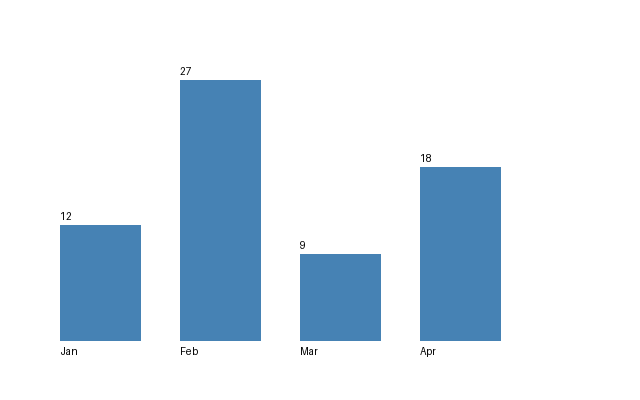

In [ ]:
from PIL import Image, ImageDraw, ImageFont

def _make_bar_chart(values, labels):
    W, H = 640, 400
    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)
    base_y, max_v = 340, max(values)
    bw = W // (len(values) * 2)
    for i, (v, lab) in enumerate(zip(values, labels)):
        x = 60 + i * (bw + 40)
        h = int((v / max_v) * 260)
        d.rectangle([x, base_y - h, x + bw, base_y], fill='steelblue')
        d.text((x, base_y + 5), lab, fill='black')
        d.text((x, base_y - h - 15), str(v), fill='black')
    return img

def _make_receipt(items):
    W, H = 360, 420
    img = Image.new('RGB', (W, H), 'white')
    d = ImageDraw.Draw(img)
    d.text((20, 20), 'CAFE RECEIPT', fill='black')
    y = 60
    for name, price in items:
        d.text((20, y), name, fill='black')
        d.text((260, y), f'${price:.2f}', fill='black')
        y += 30
    return img

# --- Build 10 tasks (mix of charts + receipts). Extend with your own images. ---
TASKS = []

chart = _make_bar_chart([12, 27, 9, 18], ['Jan', 'Feb', 'Mar', 'Apr'])
TASKS.append(dict(image=chart,
                  question='What is the difference between the highest and lowest month?',
                  answer='18'))
TASKS.append(dict(image=chart,
                  question='What is the total across all four months?',
                  answer='66'))

receipt = _make_receipt([('Coffee', 4.50), ('Tea', 3.00), ('Cake', 6.20),
                         ('Juice', 5.00), ('Sandwich', 7.80)])
TASKS.append(dict(image=receipt,
                  question='What is the total of the beverage items (Coffee, Tea, Juice)?',
                  answer='12.50'))
TASKS.append(dict(image=receipt,
                  question='What is the grand total of all items?',
                  answer='26.50'))

# TODO: add 6 more tasks of your own (aim for genuinely multi-step visual reasoning).

print(f'{len(TASKS)} tasks defined (add more for full marks).')
TASKS[0]['image']

## 4. Part A — Baseline (no tools, no loop)

Ask the model each question directly. This is your control to compare the agent against.

In [ ]:
def normalise(ans):
    """Loose normaliser so '18', '18.0', '$18' compare equal. Improve as needed."""
    s = str(ans).lower().strip().replace('$', '').replace(',', '')
    try:
        return str(round(float(s), 2))
    except ValueError:
        return s

def is_correct(pred, gold):
    return normalise(gold) in normalise(pred) or normalise(pred) == normalise(gold)

def baseline_answer(task):
    messages = [{
        'role': 'user',
        'content': [
            {'type': 'image', 'image': task['image']},
            {'type': 'text', 'text': task['question'] + ' Answer with just the number.'},
        ],
    }]
    return vlm_generate(messages, max_new_tokens=64)

# TODO: run baseline over all tasks, store predictions, and report accuracy.
baseline_correct = 0
for i, task in enumerate(TASKS):
    pred = baseline_answer(task)
    ok = is_correct(pred, task['answer'])
    baseline_correct += ok
    print(f"[{i}] pred={pred!r} gold={task['answer']!r} {'OK' if ok else 'X'}")
print(f'\nBaseline accuracy: {baseline_correct}/{len(TASKS)}')

/home/nanying/anaconda3/envs/IT3103/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[0] pred='18' gold='18' OK
[1] pred='60' gold='66' X
[2] pred='12.5' gold='12.50' OK
[3] pred='21.50' gold='26.50' X

Baseline accuracy: 2/4


## 5. Part B — Tools

Define your tools. Each tool is (1) a Python function and (2) a JSON schema the model sees.

Two tools are implemented for you as examples (`calculator`, `finish`). **You must implement
the visual tools** (`crop_region`, and at least one more, e.g. `zoom` or `read_text`).

In [ ]:
import ast, operator

# ---- Safe calculator (do NOT use eval on untrusted input) ----
_OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul,
        ast.Div: operator.truediv, ast.Pow: operator.pow, ast.USub: operator.neg}
def _safe_eval(node):
    if isinstance(node, ast.Constant):
        return node.value
    if isinstance(node, ast.BinOp):
        return _OPS[type(node.op)](_safe_eval(node.left), _safe_eval(node.right))
    if isinstance(node, ast.UnaryOp):
        return _OPS[type(node.op)](_safe_eval(node.operand))
    raise ValueError('unsupported expression')

def calculator(expression: str):
    return _safe_eval(ast.parse(expression, mode='eval').body)

# ---- TODO: implement neccesary tools here.  ----
def crop_region(box):
    """box = [x1, y1, x2, y2] in pixels. Return a cropped PIL image."""
    # TODO: return current_image.crop(tuple(box))
    raise NotImplementedError

def read_text(box=None):
    """Ask the VLM to transcribe text in a region (or whole image if box is None)."""
    # TODO: crop if box given, then call vlm_generate with a 'transcribe the text' prompt.
    raise NotImplementedError



# JSON schemas the model sees (native function-calling format).
TOOLS = [
    {'type': 'function', 'function': {
        'name': 'crop_region', 'description': 'Crop the image to a box for closer inspection.',
        'parameters': {'type': 'object', 'properties': {
            'box': {'type': 'array', 'items': {'type': 'number'},
                    'description': '[x1,y1,x2,y2] pixel coordinates'}},
            'required': ['box']}}},
    {'type': 'function', 'function': {
        'name': 'read_text', 'description': 'Transcribe text visible in a region of the image.',
        'parameters': {'type': 'object', 'properties': {
            'box': {'type': 'array', 'items': {'type': 'number'}}},
            'required': []}}},
    {'type': 'function', 'function': {
        'name': 'calculator', 'description': 'Evaluate an arithmetic expression, e.g. "12+27".',
        'parameters': {'type': 'object', 'properties': {
            'expression': {'type': 'string'}}, 'required': ['expression']}}},
]

TOOL_FNS = {'crop_region': crop_region, 'read_text': read_text,
            'calculator': calculator}


## 6. Part B — The ReAct loop

Parse the model's tool call, execute the tool, feed the observation back, repeat until
`finish` or `max_steps`.

**Parsing note:** Qwen emits tool calls inside `<tool_call>...</tool_call>` tags containing
JSON like `{"name": ..., "arguments": {...}}`. A parser helper is provided; you must wire up
the loop and handle malformed calls gracefully. The robustness is graded.

**Native observations:** with native tool calling you return each tool result through a
`role:"tool"` message. A *text* result is
a plain string; an **image** result (from `crop_region`) can ride inside the tool message as
multimodal content — `{"role":"tool","content":[{"type":"text",...},{"type":"image","image":...}]}`. Feed a crop back as an image to the conversion (not a text
description of it).

In [ ]:
import json, re

current_image = None

SYSTEM_PROMPT = (
    'You are a visual analyst agent. Think step by step. Use the provided tools to inspect '
    'the image (crop/read), compute with the calculator, and then call finish(answer). '
    'Prefer cropping to read small details. Call exactly one tool per turn.'
)

def parse_tool_call(text):
    """Extract (name, args) from a Qwen tool-call string, or (None, None) if absent."""
    m = re.search(r'<tool_call>\s*(\{.*?\})\s*</tool_call>', text, re.DOTALL)
    if not m:
        return None, None
    try:
        call = json.loads(m.group(1))
        return call.get('name'), call.get('arguments', {})
    except json.JSONDecodeError:
        return None, None  # malformed — your loop should handle this

def react_agent(task, max_steps=6, verbose=True):
    global current_image
    current_image = task['image']
    trace = []
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': [
            {'type': 'image', 'image': task['image']},
            {'type': 'text', 'text': task['question']}]},
    ]
    for step in range(max_steps):
        out = vlm_generate(messages, tools=TOOLS, max_new_tokens=384)
        # TODO: Implement the ReAct loop body:

        raise NotImplementedError('Implement the ReAct loop body.')
    return None, trace  # hit step limit without finishing

# Quick smoke test once implemented:
# ans, tr = react_agent(TASKS[0]); print('ANSWER:', ans)

## 7. Part C — Reflexion

Wrap the ReAct agent in a retry loop with **verbal self-reflection**.

Flow: actor(ReAct inner loop) → evaluate → if fail, reflect → store reflection in
memory → retry with reflections in context. Reflections must be **specific**.

In [ ]:
def evaluate(pred, task):
    """Rule-based evaluator using the ground-truth answer."""
    return is_correct(pred, task['answer'])

def reflect(task, pred, trace):
    """Ask the model to produce a SPECIFIC reflection on why the attempt failed."""
    # TODO: build a prompt containing the question, the (wrong) prediction, and a short
    #       summary of the trace, then call vlm_generate to get a 1-2 sentence reflection.
    #       Tip: pass the image back too, so the reflection can re-examine it (essential
    #       for perception/counting errors a text-only reflection cannot diagnose).
    raise NotImplementedError

def reflexion_agent(task, max_attempts=3, verbose=True):
    memory = []  # list of reflection strings
    for attempt in range(max_attempts):
        # TODO:
        #  1. run react_agent, but inject `memory` (past reflections) into its context
        #     (e.g. add them to the system prompt or as a preamble user message).
        #  2. evaluate the answer. If correct -> return (answer, attempt+1, memory).
        #  3. if wrong -> reflect(...) and append to memory, then retry.
        raise NotImplementedError('Implement the Reflexion retry loop.')
    return None, max_attempts, memory

## 8. Part C — Evaluate & compare

Produce the result comparison table: **Baseline vs ReAct vs Reflexion**, plus how accuracy improves
across retry attempts. Cope/Screenshot this table and paste it in your report.

In [ ]:
# TODO: run all three approaches over TASKS, collect accuracy, and print a comparison table.
# Also record, for Reflexion, how many tasks were solved on attempt 1 / 2 / 3.
#
# Example target output:
#   Approach     Accuracy
#   Baseline     4/10
#   ReAct        7/10
#   Reflexion    9/10   (attempt1=7, attempt2=+1, attempt3=+1)
print('TODO: implement the comparison table.')

TODO: implement the comparison table.


## 9. Report checklist (Part D)

Before you submit, make sure your `report.pdf` covers:

- [ ] Which model you used (8B or 4B) + setup (quantisation, `max_pixels`, OOM handling)
- [ ] The task dataset (10 tasks) (loop, tools, memory, evaluator)
- [ ] Tool design justification
- [ ] >= 3 documented failure cases with traces + whether ReAct/Reflexion fixed them
- [ ] Critical reflection: where did the small model struggle? Can small models reason & act?
- [ ] Results table: Baseline vs ReAct vs Reflexion

**Reminder:** you are graded on agent **engineering and analysis**, not on beating a benchmark.
Do **not** hard-code answers to the tasks.